# Regresión Logística

### 1. Imports

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from funciones_rafa import *
import joblib

### 2. Carga, división y escalado del Dataset

In [3]:
SPOOF = "..\\..\\Dataset\\Features\\spoof_features.csv"
BONAFIDE = "..\\..\\Dataset\\Features\\bonafide_features.csv"
RANDOM_STATE = 1221182

In [4]:
df = carga_datos(ruta_bon=BONAFIDE, ruta_spo=SPOOF, random_state=RANDOM_STATE)

In [5]:
X = df.drop(columns=['label', 'filename'])
y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Entrenamiento y evaluación de modelos

#### 3.1. Baseline

In [8]:
# Entrenamos el modelo con los parámetros por defecto
lr_baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_baseline.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=1221182)

In [9]:
y_pred_base = lr_baseline.predict(X_test_scaled)
y_pred_proba_base = lr_baseline.predict_proba(X_test_scaled)


==================== Regresión Logística Baseline ====================

Métricas principales:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC AUC:   1.0000
Matthews Correlation Coefficient: 1.0000

Análisis de errores:
Verdaderos Negativos (Reales bien clasificados): 10
Verdaderos Positivos (IA bien clasificados): 10
Falsos Positivos (Reales clasificados como IA): 0
Falsos Negativos (IA clasificados como Reales): 0
Error tipo I (Falsos Positivos): 0.00%
Error tipo II (Falsos Negativos): 0.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Real (1)     1.0000    1.0000    1.0000        10
      IA (0)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


Matriz de Confusión:


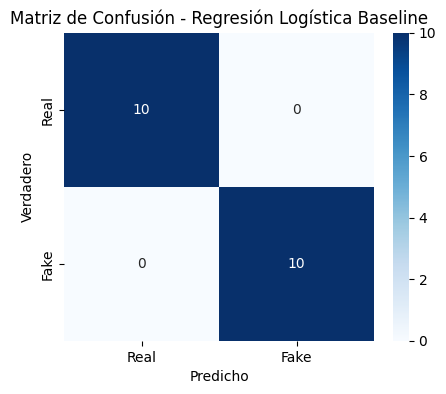

In [10]:
metrics_base = evaluacion_modelo("Regresión Logística Baseline", y_test, y_pred_base, y_pred_proba_base)

#### 3.2. Validación cruzada

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [12]:
cv_scores_accuracy = cross_val_score(lr_baseline, X_train, y_train, cv=skf, scoring='accuracy')
cv_scores_f1 = cross_val_score(lr_baseline, X_train, y_train, cv=skf, scoring='f1')
cv_scores_auc = cross_val_score(lr_baseline, X_train, y_train, cv=skf, scoring='roc_auc')

In [13]:
print("\nResultados Validación Cruzada (5 folds):")
print(f"   • Accuracy: {cv_scores_accuracy.mean():.4f} (+/- {cv_scores_accuracy.std()*2:.4f})")
print(f"   • F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")
print(f"   • AUC-ROC:  {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std()*2:.4f})")


Resultados Validación Cruzada (5 folds):
   • Accuracy: 0.9625 (+/- 0.1500)
   • F1-Score: 0.9647 (+/- 0.1412)
   • AUC-ROC:  0.9938 (+/- 0.0250)


#### 3.3. Grid search

In [14]:
# Definimos el espacio de búsqueda para Regresión Logística
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],            # Fuerza de regularización
    'solver': ['lbfgs', 'liblinear'],      # Algoritmos de optimización
    'penalty': ['l2']                      # Tipo de penalización (l2 es compatible con ambos)
}

In [15]:
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), 
    param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {grid_lr.best_params_}")

Mejores parámetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}



==================== Regresión Logística Optimizado ====================

Métricas principales:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC AUC:   1.0000
Matthews Correlation Coefficient: 1.0000

Análisis de errores:
Verdaderos Negativos (Reales bien clasificados): 10
Verdaderos Positivos (IA bien clasificados): 10
Falsos Positivos (Reales clasificados como IA): 0
Falsos Negativos (IA clasificados como Reales): 0
Error tipo I (Falsos Positivos): 0.00%
Error tipo II (Falsos Negativos): 0.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Real (1)     1.0000    1.0000    1.0000        10
      IA (0)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


Matriz de Confusión:


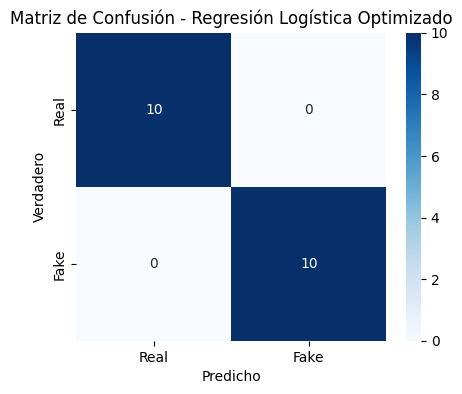

In [16]:
best_lr = grid_lr.best_estimator_
y_pred_opt = best_lr.predict(X_test_scaled)
y_pred_proba_opt = best_lr.predict_proba(X_test_scaled)

metrics_opt = evaluacion_modelo("Regresión Logística Optimizado", y_test, y_pred_opt, y_pred_proba_opt)

### 4. Guardado de scaler y mejor modelo

In [17]:
joblib.dump(best_lr, 'modelo_lr.pkl')
joblib.dump(scaler, 'scaler_lr.pkl')

print("Modelo y escalador guardados correctamente.")

Modelo y escalador guardados correctamente.
